In [2]:
import numpy as np
import matplotlib.pyplot as plt



In [4]:
# import numpy as np
# from scipy.optimize import minimize_scalar

# # Generate synthetic samples of theta
# np.random.seed(42)
# N = 1000
# theta_samples = np.random.uniform(0, 1, N)  # Random samples in [0, 2]

# # Define the empirical CDF
# def empirical_cdf(theta_samples, theta):
#     return np.mean(theta_samples <= theta)

# # Define g^-(theta) and g^+(theta)
# def compute_g(theta_samples):
#     N = len(theta_samples)
#     F_empirical = np.array([empirical_cdf(theta_samples, theta) for theta in theta_samples])
#     g_minus = theta_samples + F_empirical
#     g_plus = theta_samples - 1 + F_empirical
#     return g_minus, g_plus

# # Optimization function for q^star(theta_i)
# def optimize_q(g_minus, g_plus, lambda_param):
#     obj_best, q_best = -np.inf, 0
#     for q in np.linspace(-1, 1, 10000):
#         if q < 0:
#             obj = (g_minus - lambda_param) * q
#         else:
#             obj = (g_plus - lambda_param) * q
        
#         if obj >= obj_best:
#             obj_best = obj
#             q_best = q
#     return q_best
    

# # Solve for q^star(theta) directly
# def solve_q_star(theta_samples, lambda_param):
#     g_minus, g_plus = compute_g(theta_samples)
#     N = len(theta_samples)

#     # Compute q_star for each sample
#     q_star = np.array([optimize_q(g_minus[i], g_plus[i], lambda_param) for i in range(N)])
    
#     # Ensure zero-mean constraint by directly checking the residual
#     mean_q = np.mean(q_star)
#     # if not np.isclose(mean_q, 0, atol=1e-6):
#     #     raise ValueError(f"The given lambda does not satisfy the zero-mean constraint., {mean_q}")
    
#     return q_star

# # Example usage
# lambda_param = 0.5  # Adjust lambda to satisfy the constraint
# q_star = solve_q_star(theta_samples, lambda_param)

# # Print results
# print("Mean of q_star (should be close to 0):", np.mean(q_star))

In [245]:
import numpy as np
from bisect import bisect_left, insort

from trading_information.distributions import BetaMixture

from trading_information.distributions import BetaMixture, Uniform
from trading_information.virtual_values import VirtualValues
from scipy.interpolate import interp1d
import numpy as np

from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt


class FullyOnlineOptimizer:
    def __init__(self, lambda_param):
        self.lambda_param = lambda_param  # Regularization parameter
        self.samples = []  # To maintain a sorted list of observed samples
        self.q_sum = 0  # Running sum of q values
        self.count = 0  # Number of samples processed
        self.qts = []
        self.correction = 0

    def update_cdf(self, theta_t):
        """Insert the new sample into the sorted list for CDF updates."""
        insort(self.samples, theta_t)

    def empirical_cdf(self, theta_t):
        """Compute the empirical CDF for the current sample."""
        pos = bisect_left(self.samples, theta_t)
        return pos / len(self.samples)

    # def compute_g(self, theta_t):
    #     """Compute g^-(theta) and g^+(theta) incrementally."""
    #     F_empirical = self.empirical_cdf(theta_t)
    #     g_minus = theta_t + F_empirical
    #     g_plus = theta_t - 1 + F_empirical
    #     return g_minus, g_plus

    def compute_g(self, theta_t, positive, negative):
        """Compute g^-(theta) and g^+(theta) incrementally."""
        # F_empirical = self.empirical_cdf(theta_t)
        # g_minus = theta_t + F_empirical
        # g_plus = theta_t - 1 + F_empirical
        return negative(theta_t), positive(theta_t)


    def optimize_q(self, g_minus, g_plus, correction):
        """Solve for q^star(theta) for the current sample."""
      

        if g_plus - self.lambda_param > 0:
            return 1
        elif g_minus - self.lambda_param < 0:
            return -1
        else:
            return 0

    # def optimize_q(self, g_minus, g_plus):
    #     def objective(q):
    #         if q <= 0:
    #             return -(g_minus - self.lambda_param) * q
    #         return -(g_plus - self.lambda_param) * q

    #     x0 = [np.random.uniform(-1, 1)]
    #     res = minimize(objective, x0, bounds=[(-1, 1)])
    #     return res.x[0]



    def update(self, theta_t, positive, negative):
        """Update the solution given a new sample theta_t."""
        # Update the CDF
        self.update_cdf(theta_t)



        # Compute g^- and g^+
        g_minus, g_plus = self.compute_g(theta_t, positive, negative)

        # Optimize q_star for the current sample
        correction = self.correction
        q_t = self.optimize_q(g_minus, g_plus, correction)

        # Update running sum and count
        self.q_sum += q_t
        self.count += 1

        self.qts.append(q_t)

        mean = self.q_sum / self.count
        loss = mean**2
        self.correction = mean

        # mean = self.q_sum / self.count


       
        self.lambda_param = self.lambda_param + 1 * (1/self.count) * q_t
        return q_t

# Example usage
np.random.seed(123)
online_optimizer = FullyOnlineOptimizer(lambda_param=1)

qts = []
thetas = []
ls = []

dist = Uniform(0, 1)
dist = BetaMixture((8, 60), (30, 30), (0.5, 0.5))  # bimodal

types = np.linspace(0, 1, 10000)
virtual_values = VirtualValues(dist=dist, types=types, tau=0, prob_state0=0.5, iron=True)
positive = interp1d(x=types, y=virtual_values.positive)
negative = interp1d(x=types, y=virtual_values.negative)

thetas_all = []
qts_all = []
from tqdm import tqdm
for t in tqdm (range(10000)):
    # Simulate a new sample theta_t arriving
    theta_t = np.random.uniform(0, 1)
    
  
    # Update the optimizer with the new sample
    q_t = online_optimizer.update(theta_t, positive, negative)
   
    # if t > 9990:
    #     print(f"Step {t+1}: Theta_t = {theta_t:.3f}, Q_t = {q_t:.3f}, Running Mean = {online_optimizer.q_sum / online_optimizer.count:.6f}")

    if t > 9000:
        thetas.append(theta_t)
        qts.append(q_t)

    ls.append(online_optimizer.lambda_param)

    thetas_all.append(theta_t)
    qts_all.append(q_t)

thetas = np.array(thetas)
qts = np.array(qts)



100%|██████████| 10000/10000 [00:00<00:00, 62092.49it/s]


In [246]:
online_optimizer.lambda_param

0.6682342616373934

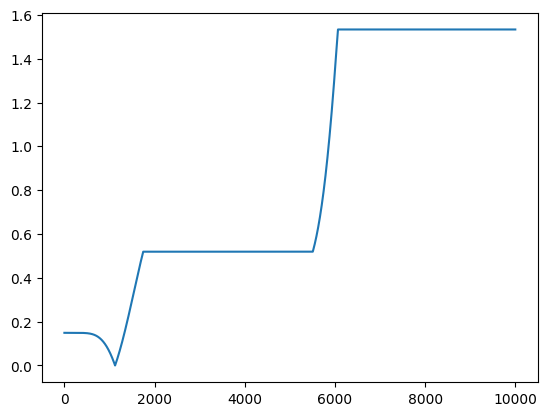

In [247]:
plt.plot(np.abs(virtual_values.negative -0.149))

In [234]:
online_optimizer.lambda_param

0.6567075337510158

In [235]:
np.mean(online_optimizer.qts[-100:])

np.float64(0.1)

In [236]:
online_optimizer.q_sum / online_optimizer.count

0.0073

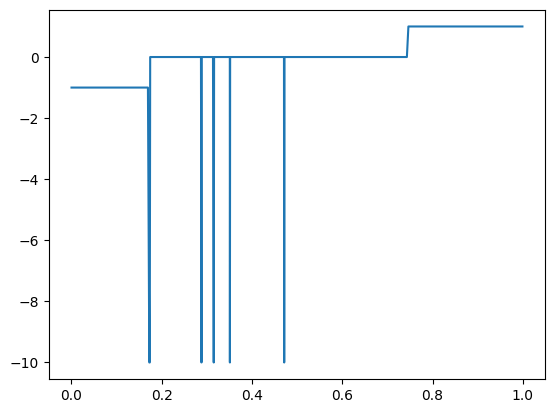

In [237]:
idx = np.argsort(thetas)

plt.plot(thetas[idx], qts[idx])

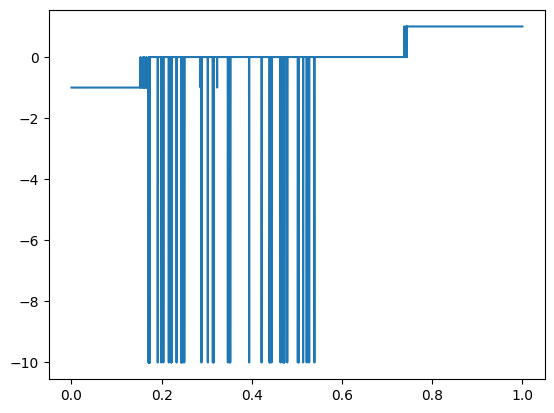

In [238]:
idx = np.argsort(thetas_all)

plt.plot(np.array(thetas_all)[idx], np.array(qts_all)[idx])

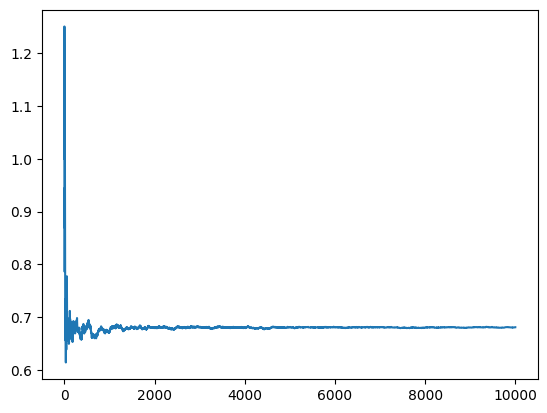

In [11]:
plt.plot(ls)